# Anomaly detection with the new `AnomalyDetector` class

This notebook showcases the redesigned anomaly-detection class in `mnplib`.

The new class identifies **model-relative anomalies**: samples whose observed target values are poorly explained by a model or prediction vector. This is intentionally weaker, and more precise, than saying that the samples are objectively wrong or corrupted.

The new workflow is:

```python
from mnplib.anomalies import AnomalyDetector

detector = AnomalyDetector(...)
detector.fit(X, y, model=model)
# or:
detector.fit_predictions(X, y, predictions)

detector.summary()
detector.anomalies()
detector.anomaly_scores()
detector.anomaly_table()
detector.group_anomalies()
detector.group_points(...)
detector.explain()
```

The notebook covers:

- regression anomalies from residuals;
- under-predicted and over-predicted anomalies;
- anomaly scores and anomaly tables;
- anomaly grouping with KMeans;
- classification anomalies from misclassification;
- probability-based classification anomalies;
- functional `anomaly_table`;
- optional automatic model-selection delegation.


## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import accuracy_score, r2_score

from nescience.anomalies import AnomalyDetector, anomaly_table

pd.set_option("display.max_columns", None)
plt.rcParams["figure.figsize"] = (11, 4)

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

## 2. Helper functions

In [2]:
def plot_anomaly_scores(detector, title):
    """Plot anomaly scores and detected anomalies."""
    scores = detector.anomaly_scores()
    anomalies = detector.anomalies()

    plt.figure(figsize=(11, 4))
    plt.plot(scores, marker="o", linewidth=1, label="Anomaly score")
    if detector.anomaly_threshold_ is not None:
        plt.axhline(detector.anomaly_threshold_, linestyle="--", label="Threshold")
    if len(anomalies) > 0:
        plt.scatter(anomalies, scores[anomalies], marker="x", s=80, label="Detected anomalies")
    plt.title(title)
    plt.xlabel("Sample index")
    plt.ylabel("Score")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_regression_fit(y, y_pred, anomalies, title):
    """Plot observed and predicted target values."""
    plt.figure(figsize=(11, 4))
    plt.plot(y, label="Observed")
    plt.plot(y_pred, label="Predicted")
    if len(anomalies) > 0:
        plt.scatter(anomalies, np.asarray(y)[anomalies], marker="x", s=80, label="Anomalies")
    plt.title(title)
    plt.xlabel("Sample index")
    plt.ylabel("Target")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_group_points(points, feature_name, title):
    """Plot clustered anomaly points for a one-dimensional grouping."""
    plt.figure(figsize=(10, 4))
    for cluster, frame in points.groupby("cluster"):
        plt.scatter(frame[feature_name], frame["anomaly_score"], label=f"Cluster {cluster}")
    plt.title(title)
    plt.xlabel(feature_name)
    plt.ylabel("Anomaly score")
    plt.legend()
    plt.tight_layout()
    plt.show()


def compact_anomaly_table(detector, n=10):
    """Return the first rows of the anomaly table, sorted by score."""
    table = detector.anomaly_table()
    return table.sort_values("anomaly_score", ascending=False).head(n)


## 3. Regression example: residual-based anomalies

We create a clean regression problem and then inject a few target deviations. The detector is fitted from a supplied prediction vector, which is useful when predictions are produced by an external workflow.


In [3]:
n_samples = 120

x_signal = np.linspace(-4, 4, n_samples)
x_auxiliary = rng.normal(size=n_samples)
x_noise = rng.normal(size=n_samples)

X_reg = pd.DataFrame(
    {
        "signal": x_signal,
        "auxiliary": x_auxiliary,
        "noise": x_noise,
    }
)

y_clean = 3.0 * x_signal - 0.8 * x_auxiliary + rng.normal(scale=0.25, size=n_samples)
y_observed = y_clean.copy()

# Inject interpretable target deviations.
injected_under = [18, 67]
injected_over = [43, 101]
y_observed[injected_under] += 12.0
y_observed[injected_over] -= 12.0

# A simple predictive baseline intentionally does not explain the injected deviations.
regressor = LinearRegression().fit(X_reg, y_observed)
y_pred = regressor.predict(X_reg)

print("R2 of supplied prediction model:", r2_score(y_observed, y_pred))


R2 of supplied prediction model: 0.9095827661871042


In [4]:
detector_reg = AnomalyDetector(
    task="regression",
    anomaly_rule="residual_quantile",
    anomaly_quantile=0.92,
    random_state=RANDOM_SEED,
)

detector_reg.fit_predictions(X_reg, y_observed, y_pred)

detector_reg.summary()


{'task': 'regression',
 'anomaly_rule': 'residual_quantile',
 'n_samples': 120,
 'n_features': 3,
 'n_anomalies': 10,
 'anomaly_rate': 0.08333333333333333,
 'model_type': None,
 'threshold': 0.6574932180796267,
 'mean_absolute_residual': 0.6755934035878212,
 'median_absolute_residual': 0.2610282368132262,
 'n_under_predicted': 59,
 'n_over_predicted': 61}

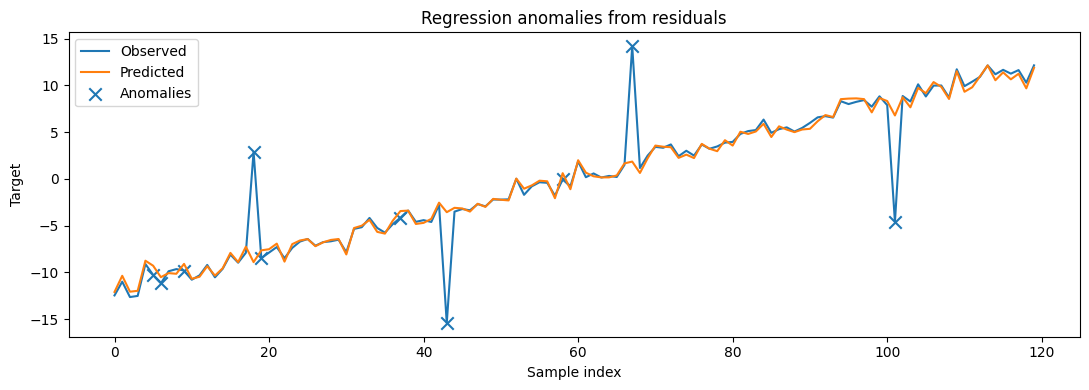

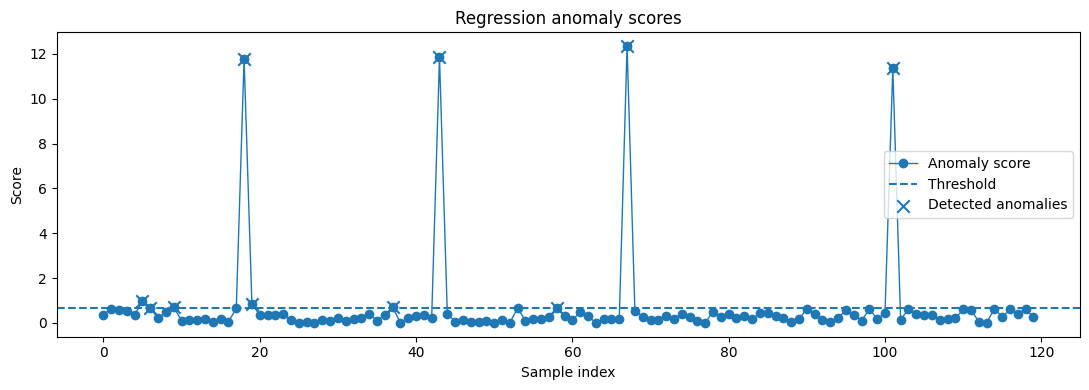

In [5]:
plot_regression_fit(
    y_observed,
    detector_reg.y_pred_,
    detector_reg.anomalies(),
    "Regression anomalies from residuals",
)

plot_anomaly_scores(detector_reg, "Regression anomaly scores")


## 4. Regression anomaly table

In [6]:
compact_anomaly_table(detector_reg, n=12)

,sample_index,y_true,y_pred,anomaly_score,is_anomaly,anomaly_kind,residual,absolute_residual,standardized_residual,direction
8,67,14.207498,1.858935,12.348562,True,under_predicted,12.348562,12.348562,31.908391,under_predicted
6,43,-15.399855,-3.554670,11.845185,True,over_predicted,-11.845185,11.845185,30.607677,over_predicted
3,18,2.894036,-8.900319,11.794355,True,under_predicted,11.794355,11.794355,30.476333,under_predicted
9,101,-4.593543,6.794211,11.387754,True,over_predicted,-11.387754,11.387754,29.425686,over_predicted
0,5,-10.271709,-9.283041,0.988667,True,over_predicted,-0.988667,0.988667,2.554693,over_predicted
4,19,-8.471850,-7.637743,0.834107,True,over_predicted,-0.834107,0.834107,2.155313,over_predicted
5,37,-4.143793,-3.435408,0.708385,True,over_predicted,-0.708385,0.708385,1.830450,over_predicted
2,9,-9.795330,-9.087631,0.707700,True,over_predicted,-0.707700,0.707700,1.828679,over_predicted
7,58,-0.049037,0.617714,0.666750,True,over_predicted,-0.666750,0.666750,1.722867,over_predicted
1,6,-11.166385,-10.506785,0.659600,True,over_predicted,-0.659600,0.659600,1.704390,over_predicted


## 5. Under-predicted and over-predicted anomalies

For regression, the detector can separate anomalies according to prediction direction.

- `under_predicted`: the model predicted too small a value;
- `over_predicted`: the model predicted too large a value.


In [7]:
under_predicted = detector_reg.anomalies(kind="under_predicted")
over_predicted = detector_reg.anomalies(kind="over_predicted")

print("Under-predicted anomaly indices:", under_predicted)
print("Over-predicted anomaly indices:", over_predicted)

detector_reg.anomaly_table().groupby("direction").size()

Under-predicted anomaly indices: [18 67]
Over-predicted anomaly indices: [  5   6   9  19  37  43  58 101]


direction
over_predicted     8
under_predicted    2
dtype: int64

## 6. Alternative regression rules

The redesigned class supports several regression anomaly rules. Here we compare:

- `residual_quantile`;
- `standardized_residual`;
- `bin_mismatch`.


In [8]:
rule_rows = []

for rule, kwargs in [
    ("residual_quantile", {"anomaly_quantile": 0.92}),
    ("standardized_residual", {"z_score_threshold": 3.0}),
    ("bin_mismatch", {"n_bins": 6}),
]:
    detector = AnomalyDetector(
        task="regression",
        anomaly_rule=rule,
        random_state=RANDOM_SEED,
        **kwargs,
    )
    detector.fit_predictions(X_reg, y_observed, y_pred)
    summary = detector.summary()
    rule_rows.append(
        {
            "rule": rule,
            "n_anomalies": summary["n_anomalies"],
            "anomaly_rate": summary["anomaly_rate"],
            "threshold": summary["threshold"],
        }
    )

pd.DataFrame(rule_rows)

,rule,n_anomalies,anomaly_rate,threshold
0,residual_quantile,10,0.083333,0.657493
1,standardized_residual,4,0.033333,3.000000
2,bin_mismatch,35,0.291667,NaN


## 7. Fitting from a supplied model

The detector can also receive a model. If `fit_model=True`, it clones and fits the supplied estimator before producing predictions.


In [9]:
tree_detector = AnomalyDetector(
    task="regression",
    anomaly_rule="residual_quantile",
    anomaly_quantile=0.92,
    fit_model=True,
    random_state=RANDOM_SEED,
)

tree_detector.fit(
    X_reg,
    y_observed,
    model=DecisionTreeRegressor(max_depth=3, random_state=RANDOM_SEED),
)

print(tree_detector.summary())
compact_anomaly_table(tree_detector, n=8)


{'task': 'regression', 'anomaly_rule': 'residual_quantile', 'n_samples': 120, 'n_features': 3, 'n_anomalies': 10, 'anomaly_rate': 0.08333333333333333, 'model_type': 'DecisionTreeRegressor', 'threshold': 3.4024938048406486, 'mean_absolute_residual': 1.516336100887934, 'median_absolute_residual': 1.0927160728119276, 'n_under_predicted': 59, 'n_over_predicted': 61}


,sample_index,y_true,y_pred,anomaly_score,is_anomaly,anomaly_kind,residual,absolute_residual,standardized_residual,direction
1,43,-15.399855,-5.939437,9.460418,True,over_predicted,-9.460418,9.460418,5.899738,over_predicted
6,67,14.207498,4.970772,9.236726,True,under_predicted,9.236726,9.236726,5.760238,under_predicted
0,18,2.894036,-5.939437,8.833473,True,under_predicted,8.833473,8.833473,5.508760,under_predicted
4,63,0.154773,4.970772,4.815999,True,over_predicted,-4.815999,4.815999,3.003369,over_predicted
2,61,0.186964,4.970772,4.783808,True,over_predicted,-4.783808,4.783808,2.983294,over_predicted
3,62,0.589956,4.970772,4.380815,True,over_predicted,-4.380815,4.380815,2.731979,over_predicted
9,101,-4.593543,-0.721346,3.872197,True,over_predicted,-3.872197,3.872197,2.414793,over_predicted
8,99,8.842960,4.970772,3.872188,True,under_predicted,3.872188,3.872188,2.414787,under_predicted


## 8. Grouping anomalies by their characteristics

The detector can propose simple one- or two-dimensional groupings of the anomalous samples. Each candidate grouping is obtained by clustering the anomalous rows in a standardized attribute subspace.


In [10]:
groups_1d = detector_reg.group_anomalies(
    dimensions=1,
    max_groups=5,
    filter_redundant=False,
)

groups_1d


,attribute_1,attribute_1_name,attribute_2,attribute_2_name,dimensions,inertia,cluster_0_size,cluster_1_size,balance,n_anomalies
0,2,noise,None,None,1,2.585048,4,6,0.4,10
1,1,auxiliary,None,None,1,2.621854,5,5,0.5,10
2,0,signal,None,None,1,2.681410,7,3,0.3,10


In [11]:
best_attribute = groups_1d.iloc[0]["attribute_1_name"]
points = detector_reg.group_points(best_attribute)

points.head()


,sample_index,cluster,y_true,y_pred,anomaly_score,noise
0,18,0,2.894036,-8.900319,11.794355,1.996731
1,19,0,-8.471850,-7.637743,0.834107,2.913862
2,37,0,-4.143793,-3.435408,0.708385,0.982740
3,6,0,-11.166385,-10.506785,0.659600,1.463303
4,67,1,14.207498,1.858935,12.348562,-1.224469


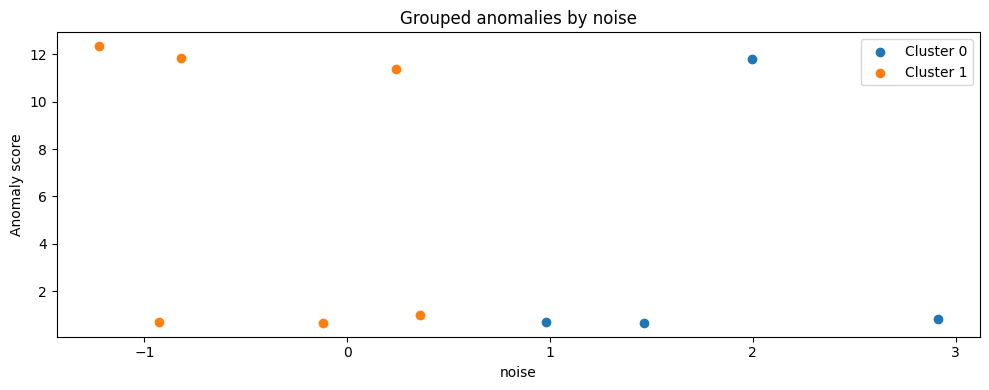

In [12]:
plot_group_points(
    points,
    best_attribute,
    f"Grouped anomalies by {best_attribute}",
)


## 9. Two-dimensional anomaly groups

In [13]:
groups_2d = detector_reg.group_anomalies(
    dimensions=2,
    max_groups=5,
    filter_redundant=False,
    filter_repeated_attributes=True,
)

groups_2d


,attribute_1,attribute_1_name,attribute_2,attribute_2_name,dimensions,inertia,cluster_0_size,cluster_1_size,balance,n_anomalies
0,1,auxiliary,2,noise,2,8.551482,4,6,0.4,10


## 10. A synthetic grouping-focused example

The previous regression dataset has only a few injected anomalies. In this example, we create more anomalous rows with two visible subgroups so that `group_anomalies()` has a clearer structure to discover.


In [14]:
n_group = 100

X_group = pd.DataFrame(
    {
        "group_axis": np.r_[
            rng.normal(-4.0, 0.25, 15),
            rng.normal(4.0, 0.25, 15),
            rng.normal(0.0, 1.00, n_group - 30),
        ],
        "secondary_axis": np.r_[
            rng.normal(2.0, 0.30, 15),
            rng.normal(-2.0, 0.30, 15),
            rng.normal(0.0, 1.00, n_group - 30),
        ],
        "noise_axis": rng.normal(0.0, 1.0, n_group),
    }
)

y_group = rng.normal(0.0, 1.0, n_group)
pred_group = y_group.copy()
pred_group[:30] += 10.0

group_detector = AnomalyDetector(
    task="regression",
    anomaly_rule="residual_quantile",
    anomaly_quantile=0.70,
    random_state=RANDOM_SEED,
)

group_detector.fit_predictions(X_group, y_group, pred_group)
group_detector.summary()


{'task': 'regression',
 'anomaly_rule': 'residual_quantile',
 'n_samples': 100,
 'n_features': 3,
 'n_anomalies': 30,
 'anomaly_rate': 0.3,
 'model_type': None,
 'threshold': 2.9999999999999716,
 'mean_absolute_residual': 3.0,
 'median_absolute_residual': 0.0,
 'n_under_predicted': 0,
 'n_over_predicted': 30}

In [15]:
group_detector.group_anomalies(
    dimensions=1,
    max_groups=5,
    filter_redundant=False,
)


,attribute_1,attribute_1_name,attribute_2,attribute_2_name,dimensions,inertia,cluster_0_size,cluster_1_size,balance,n_anomalies
0,0,group_axis,None,None,1,0.128122,15,15,0.500000,30
1,1,secondary_axis,None,None,1,0.659439,15,15,0.500000,30
2,2,noise_axis,None,None,1,10.513537,20,10,0.333333,30


In [16]:
group_detector.group_anomalies(
    dimensions=2,
    max_groups=5,
    filter_redundant=False,
)


,attribute_1,attribute_1_name,attribute_2,attribute_2_name,dimensions,inertia,cluster_0_size,cluster_1_size,balance,n_anomalies
0,0,group_axis,1,secondary_axis,2,0.787562,15,15,0.5,30


In [17]:
points = group_detector.group_points("group_axis", "secondary_axis")
points.head()


,sample_index,cluster,y_true,y_pred,anomaly_score,group_axis,secondary_axis
0,0,0,-1.691963,8.308037,10.0,-4.038131,2.094172
1,1,0,-0.017563,9.982437,10.0,-3.904152,1.749989
2,2,0,-0.902423,9.097577,10.0,-3.750044,1.523130
3,3,0,-0.342341,9.657659,10.0,-4.264634,1.378105
4,4,0,-0.081588,9.918412,10.0,-4.031252,1.664785


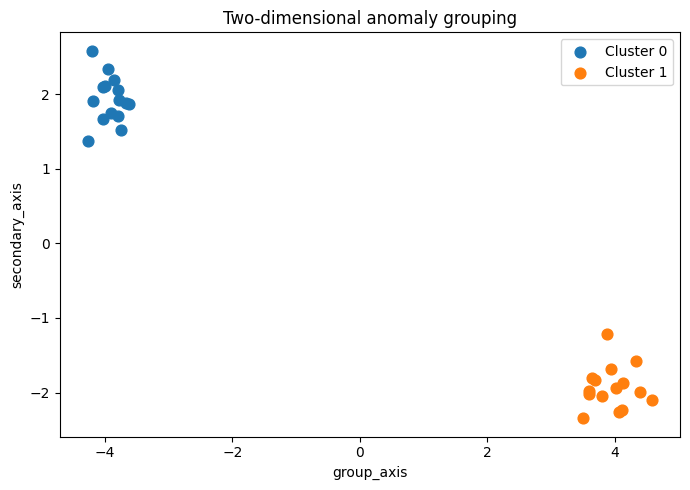

In [18]:
plt.figure(figsize=(7, 5))
for cluster, frame in points.groupby("cluster"):
    plt.scatter(
        frame["group_axis"],
        frame["secondary_axis"],
        label=f"Cluster {cluster}",
        s=60,
    )
plt.title("Two-dimensional anomaly grouping")
plt.xlabel("group_axis")
plt.ylabel("secondary_axis")
plt.legend()
plt.tight_layout()
plt.show()


## 11. Classification example: misclassification anomalies

For classification, the default rule marks samples as anomalous when the predicted label differs from the observed label.


In [19]:
X_cls_array, y_cls = make_classification(
    n_samples=160,
    n_features=5,
    n_informative=3,
    n_redundant=0,
    n_classes=2,
    random_state=RANDOM_SEED,
)

X_cls = pd.DataFrame(
    X_cls_array,
    columns=[f"feature_{i}" for i in range(X_cls_array.shape[1])],
)

classifier = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)
classifier.fit(X_cls, y_cls)
y_cls_pred = classifier.predict(X_cls)

print("Training accuracy:", accuracy_score(y_cls, y_cls_pred))


Training accuracy: 0.84375


In [20]:
detector_cls = AnomalyDetector(
    task="classification",
    anomaly_rule="misclassification",
    random_state=RANDOM_SEED,
)

detector_cls.fit_predictions(X_cls, y_cls, y_cls_pred)

detector_cls.summary()


{'task': 'classification',
 'anomaly_rule': 'misclassification',
 'n_samples': 160,
 'n_features': 5,
 'n_anomalies': 25,
 'anomaly_rate': 0.15625,
 'model_type': None,
 'threshold': None,
 'n_misclassified': 25}

In [21]:
detector_cls.anomaly_table().head(10)


,sample_index,y_true,y_pred,anomaly_score,is_anomaly,anomaly_kind,correct
0,1,0,1,1.0,True,misclassified,False
1,3,1,0,1.0,True,misclassified,False
2,5,1,0,1.0,True,misclassified,False
3,23,1,0,1.0,True,misclassified,False
4,27,0,1,1.0,True,misclassified,False
5,29,1,0,1.0,True,misclassified,False
6,39,0,1,1.0,True,misclassified,False
7,40,1,0,1.0,True,misclassified,False
8,45,0,1,1.0,True,misclassified,False
9,49,0,1,1.0,True,misclassified,False


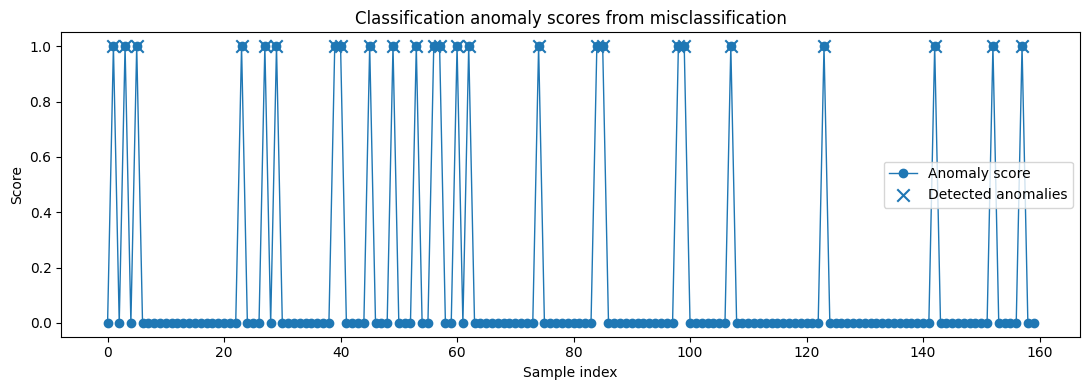

In [22]:
plot_anomaly_scores(detector_cls, "Classification anomaly scores from misclassification")


## 12. Probability-based classification anomalies

If the model supports `predict_proba`, the detector can rank samples by the lack of probability assigned to the true class.


In [23]:
prob_detector = AnomalyDetector(
    task="classification",
    anomaly_rule="probability_quantile",
    anomaly_quantile=0.90,
    fit_model=True,
    random_state=RANDOM_SEED,
)

prob_detector.fit(
    X_cls,
    y_cls,
    model=LogisticRegression(max_iter=1000, random_state=RANDOM_SEED),
)

prob_detector.summary()


{'task': 'classification',
 'anomaly_rule': 'probability_quantile',
 'n_samples': 160,
 'n_features': 5,
 'n_anomalies': 16,
 'anomaly_rate': 0.1,
 'model_type': 'LogisticRegression',
 'threshold': 0.5830009154298609,
 'n_misclassified': 25}

In [24]:
prob_detector.anomaly_table().head(10)


,sample_index,y_true,y_pred,anomaly_score,is_anomaly,anomaly_kind,correct,true_class_probability
0,1,0,1,0.807514,True,misclassified,False,0.192486
1,3,1,0,0.619895,True,misclassified,False,0.380105
2,5,1,0,0.963840,True,misclassified,False,0.036160
3,27,0,1,0.614303,True,misclassified,False,0.385697
4,29,1,0,0.708296,True,misclassified,False,0.291704
5,39,0,1,0.588353,True,misclassified,False,0.411647
6,40,1,0,0.901240,True,misclassified,False,0.098760
7,45,0,1,0.919779,True,misclassified,False,0.080221
8,53,1,0,0.961671,True,misclassified,False,0.038329
9,60,0,1,0.584019,True,misclassified,False,0.415981


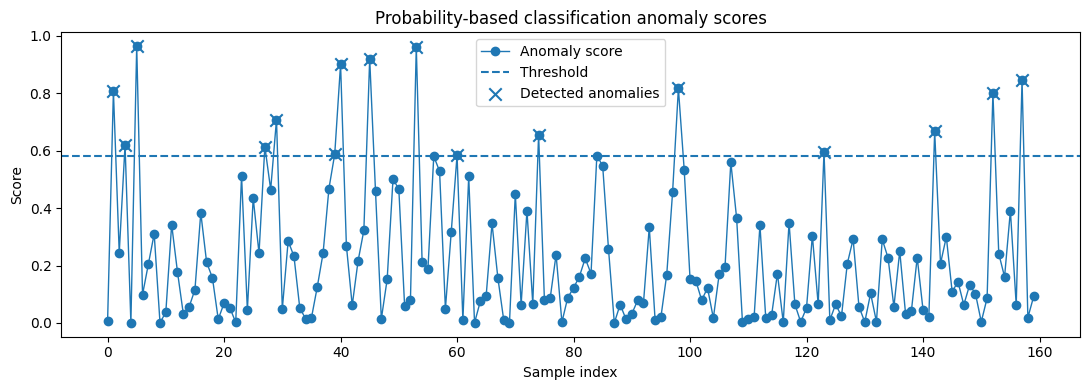

In [25]:
plot_anomaly_scores(prob_detector, "Probability-based classification anomaly scores")


## 13. String class labels

The detector also supports non-numeric class labels.


In [26]:
y_string = np.array([f"class_{label}" for label in y_cls])
y_string_pred = np.array([f"class_{label}" for label in y_cls_pred])

string_detector = AnomalyDetector(task="classification")
string_detector.fit_predictions(X_cls, y_string, y_string_pred)

string_detector.anomaly_table().head()


,sample_index,y_true,y_pred,anomaly_score,is_anomaly,anomaly_kind,correct
0,1,class_0,class_1,1.0,True,misclassified,False
1,3,class_1,class_0,1.0,True,misclassified,False
2,5,class_1,class_0,1.0,True,misclassified,False
3,23,class_1,class_0,1.0,True,misclassified,False
4,27,class_0,class_1,1.0,True,misclassified,False


## 14. Functional interface

For quick analysis from an existing prediction vector, use the functional `anomaly_table()` helper.


In [27]:
quick_table = anomaly_table(
    X_reg,
    y_observed,
    y_pred,
    task="regression",
    anomaly_rule="residual_quantile",
    anomaly_quantile=0.92,
)

quick_table.head(10)


,sample_index,y_true,y_pred,anomaly_score,is_anomaly,anomaly_kind,residual,absolute_residual,standardized_residual,direction
0,5,-10.271709,-9.283041,0.988667,True,over_predicted,-0.988667,0.988667,2.554693,over_predicted
1,6,-11.166385,-10.506785,0.659600,True,over_predicted,-0.659600,0.659600,1.704390,over_predicted
2,9,-9.795330,-9.087631,0.707700,True,over_predicted,-0.707700,0.707700,1.828679,over_predicted
3,18,2.894036,-8.900319,11.794355,True,under_predicted,11.794355,11.794355,30.476333,under_predicted
4,19,-8.471850,-7.637743,0.834107,True,over_predicted,-0.834107,0.834107,2.155313,over_predicted
5,37,-4.143793,-3.435408,0.708385,True,over_predicted,-0.708385,0.708385,1.830450,over_predicted
6,43,-15.399855,-3.554670,11.845185,True,over_predicted,-11.845185,11.845185,30.607677,over_predicted
7,58,-0.049037,0.617714,0.666750,True,over_predicted,-0.666750,0.666750,1.722867,over_predicted
8,67,14.207498,1.858935,12.348562,True,under_predicted,12.348562,12.348562,31.908391,under_predicted
9,101,-4.593543,6.794211,11.387754,True,over_predicted,-11.387754,11.387754,29.425686,over_predicted


## 15. Explanation object

The `explain()` method returns a compact dictionary designed for reports or user interfaces.


In [28]:
detector_reg.explain()


{'summary': {'task': 'regression',
  'anomaly_rule': 'residual_quantile',
  'n_samples': 120,
  'n_features': 3,
  'n_anomalies': 10,
  'anomaly_rate': 0.08333333333333333,
  'model_type': None,
  'threshold': 0.6574932180796267,
  'mean_absolute_residual': 0.6755934035878212,
  'median_absolute_residual': 0.2610282368132262,
  'n_under_predicted': 59,
  'n_over_predicted': 61},
 'feature_names': ['signal', 'auxiliary', 'noise'],
 'recommendation': 'Inspect the anomaly table and group candidates. High-scoring rows are observations least explained by the fitted model or supplied prediction vector. For regression, compare under-predicted and over-predicted subsets separately because they often correspond to different mechanisms.'}

## 16. Optional: automatic model selection

If the current installation includes `NescienceRegressor` and `NescienceClassifier`, the detector can delegate model selection to them when no model and no predictions are supplied.

This cell is intentionally guarded so the notebook still runs in minimal environments.


In [29]:
try:
    auto_detector = AnomalyDetector(
        task="regression",
        anomaly_rule="residual_quantile",
        anomaly_quantile=0.92,
        auto_model_kwargs={"aggregation": "euclidean"},
        random_state=RANDOM_SEED,
    )
    auto_detector.fit(X_reg, y_observed)

    print("Automatic model type:", type(auto_detector.model_).__name__)
    print(auto_detector.summary())
    display(auto_detector.anomaly_table().head())
except (ImportError, TypeError, ValueError) as exc:
    print("Automatic model-selection example skipped:")
    print(type(exc).__name__ + ":", exc)


Automatic model-selection example skipped:
TypeError: Miscoding.__init__() got an unexpected keyword argument 'threshold_fraction'


## 17. Summary

The redesigned anomaly API is centered on model-relative explanations:

```python
detector = AnomalyDetector(...)
detector.fit(X, y, model=model)
detector.fit_predictions(X, y, predictions)

detector.summary()
detector.anomalies()
detector.anomaly_scores()
detector.anomaly_table()
detector.group_anomalies()
detector.group_points(...)
detector.explain()
```

The main practical improvement over the old class is that anomaly detection is no longer just a list of indices. The detector now provides scores, explanations, anomaly types, grouping candidates, and integration points for both external models and nescience-based automatic model selection.
